In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("mobile_game_inapp_purchases.csv")
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

In [5]:
# Check nulls
df.isnull().sum()

,0
UserID,0
Age,60
Gender,60
Country,60
Device,60
GameGenre,60
SessionCount,0
AverageSessionLength,0
SpendingSegment,0
InAppPurchaseAmount,136


In [6]:
# Feature engineering
df['TotalPlayTime'] = df['SessionCount'] * df['AverageSessionLength']

In [7]:
# High engagement flag (top 25% by total playtime)
threshold = df['TotalPlayTime'].quantile(0.75)
df['HighEngagementFlag'] = df['TotalPlayTime'] >= threshold

In [8]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,18,25,35,50,100],
                        labels=['<18','18-25','26-35','36-50','50+'])

In [9]:
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,TotalPlayTime,HighEngagementFlag,AgeGroup
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19,115.47,False,36-50
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08,213.29,False,<18
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02,79.83,False,18-25
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01,234.72,False,26-35
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05,152.30,False,36-50


In [10]:
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'], errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   UserID                         3024 non-null   object        
 1   Age                            2964 non-null   float64       
 2   Gender                         2964 non-null   object        
 3   Country                        2964 non-null   object        
 4   Device                         2964 non-null   object        
 5   GameGenre                      2964 non-null   object        
 6   SessionCount                   3024 non-null   int64         
 7   AverageSessionLength           3024 non-null   float64       
 8   SpendingSegment                3024 non-null   object        
 9   InAppPurchaseAmount            2888 non-null   float64       
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64       
 11  PaymentMethod    

In [12]:
df.describe()

,Age,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,LastPurchaseDate,TotalPlayTime
count,2964.000000,3024.000000,3024.000000,2888.000000,2888.000000,2888,3024.000000
mean,33.533738,10.074735,20.073978,102.582864,15.384003,2025-04-24 16:33:14.459833600,201.957553
min,13.000000,1.000000,5.010000,0.000000,0.000000,2025-01-01 00:00:00,11.010000
25%,23.000000,8.000000,12.680000,5.987500,8.000000,2025-02-28 00:00:00,115.920000
50%,33.000000,10.000000,20.315000,11.975000,16.000000,2025-04-26 00:00:00,186.375000
75%,44.000000,12.000000,27.420000,17.762500,23.000000,2025-06-20 00:00:00,273.210000
max,54.000000,22.000000,34.990000,4964.450000,30.000000,2025-08-13 00:00:00,732.160000
std,11.992258,3.115863,8.585208,454.339708,8.946191,NaN,109.139207


# Handling Null Values

In [13]:
df = df.dropna(subset=['Age', 'Gender', 'Country', 'Device', 'GameGenre'])

InAppPurchaseAmount = 0 → no purchases.

FirstPurchaseDaysAfterInstall = -1 → helps distinguish non-paying players in analysis.

PaymentMethod = 'None' → means didn't bought single time.

In [14]:
# Non-spenders
df['InAppPurchaseAmount'] = df['InAppPurchaseAmount'].fillna(0)
df['FirstPurchaseDaysAfterInstall'] = df['FirstPurchaseDaysAfterInstall'].fillna(-1)
df['PaymentMethod'] = df['PaymentMethod'].fillna('None')

# E.D.A.

## Univariant Analysis

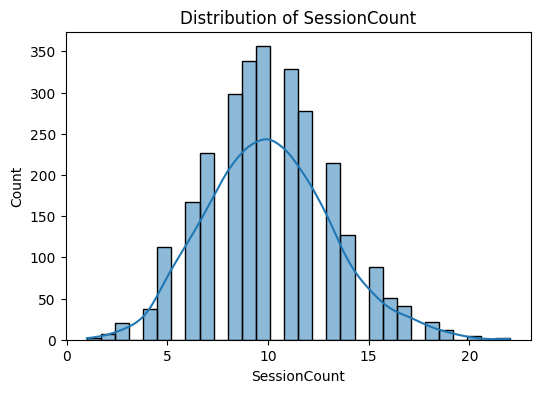

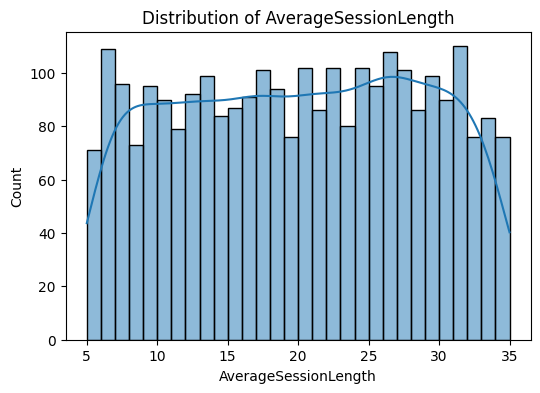

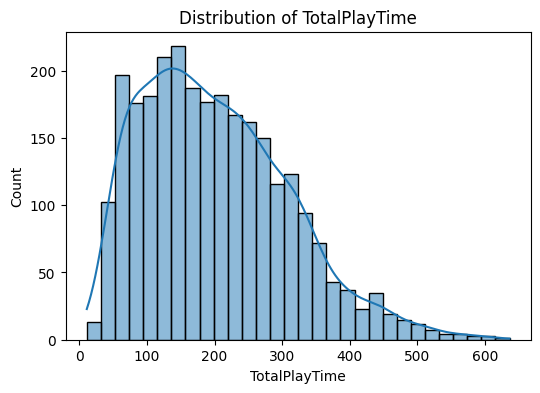

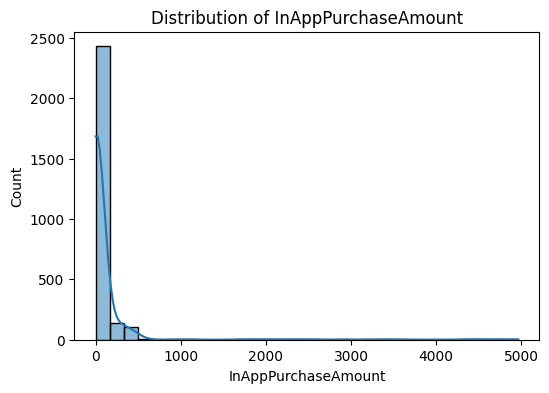

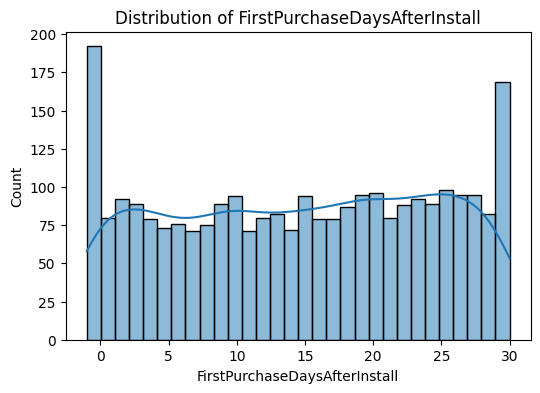

In [46]:
numeric_cols = ['SessionCount','AverageSessionLength','TotalPlayTime','InAppPurchaseAmount','FirstPurchaseDaysAfterInstall']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

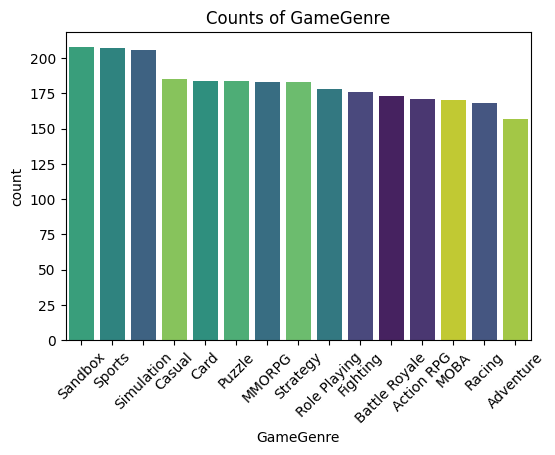

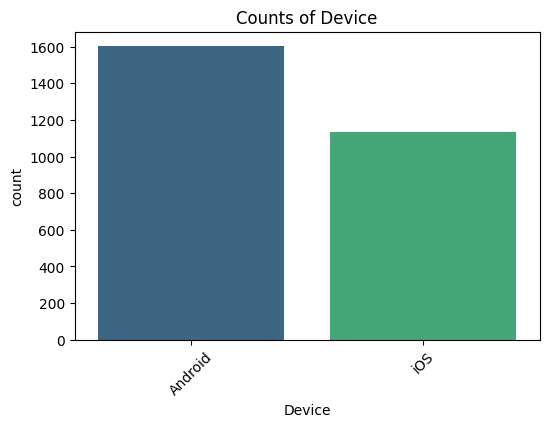

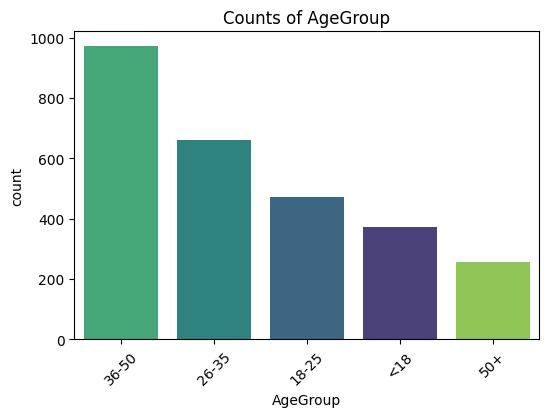

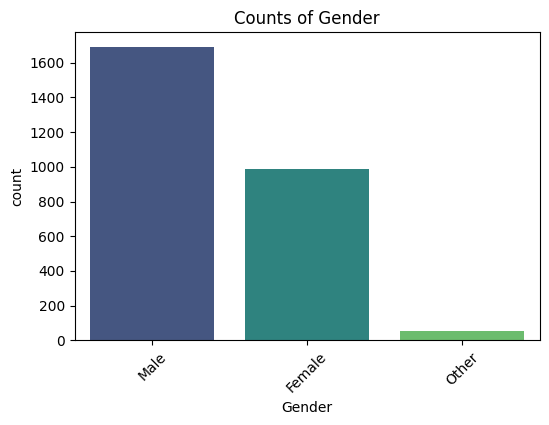

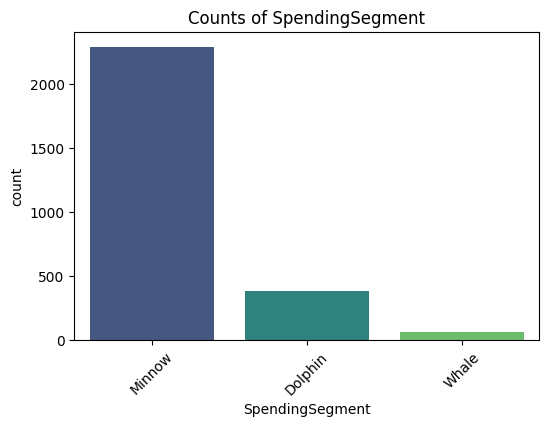

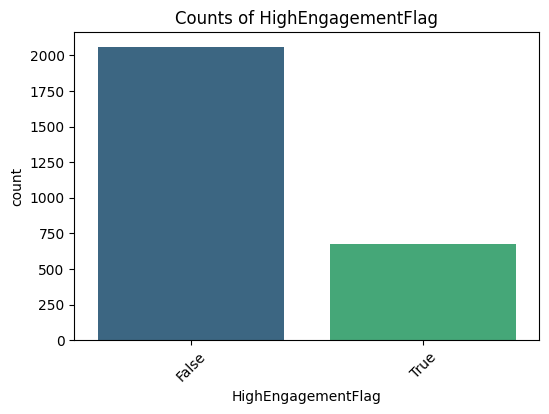

In [48]:
categorical_cols = ['GameGenre','Device','AgeGroup','Gender','SpendingSegment','HighEngagementFlag']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], palette='viridis',hue = df[col], legend=False, order=df[col].value_counts().index)
    plt.title(f'Counts of {col}')
    plt.xticks(rotation=45)
    plt.show()

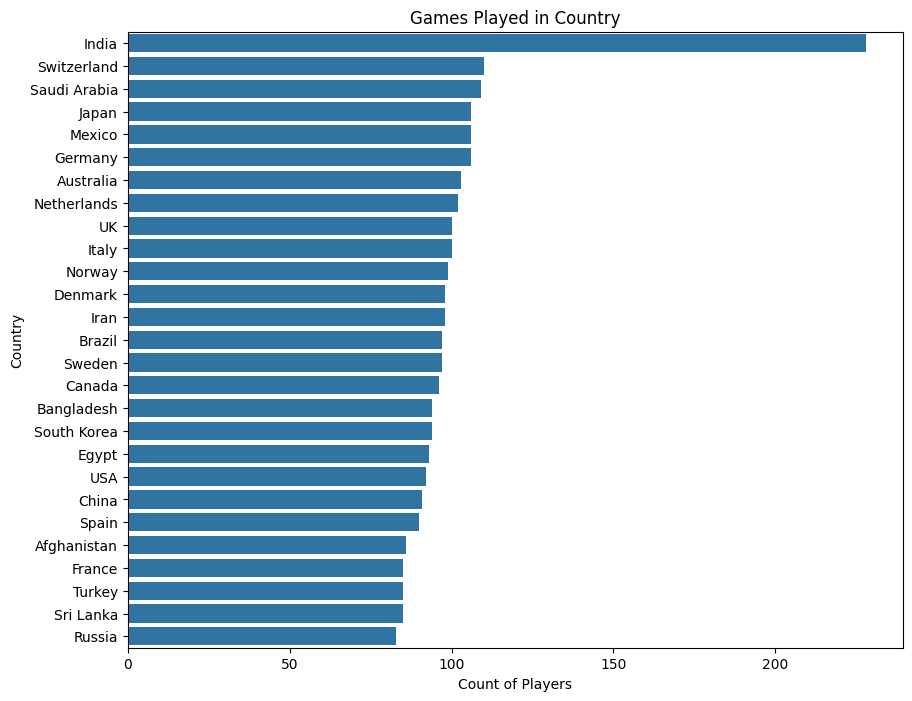

In [54]:
country_count = df['Country'].value_counts()
plt.figure(figsize=(10,8))
sns.barplot(x= country_count.values, y = country_count.index)
plt.title('Games Played in Country')
plt.ylabel('Country')
plt.xlabel('Count of Players')
plt.show()

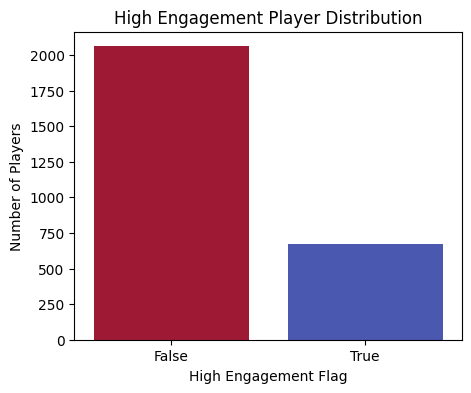

In [27]:
high_engagement_counts = df['HighEngagementFlag'].value_counts()

plt.figure(figsize=(5,4))
sns.barplot(x=high_engagement_counts.index, y=high_engagement_counts.values, palette='coolwarm', hue = high_engagement_counts,legend=False)
plt.title('High Engagement Player Distribution')
plt.ylabel('Number of Players')
plt.xlabel('High Engagement Flag')
plt.show()

In [32]:
# Count of high and low engagement players
counts = df['HighEngagementFlag'].value_counts()

# Percentage
percentages = counts / counts.sum() * 100

HighEngagementFlag
False    75.375046
True     24.624954
Name: count, dtype: float64


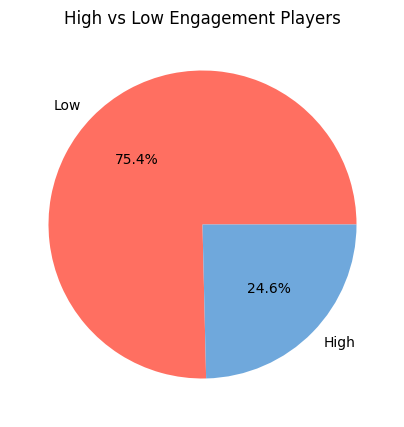

In [33]:
plt.figure(figsize=(5,5))
plt.pie(percentages.values, labels=['Low','High'], autopct='%1.1f%%', colors=['#FF6F61','#6FA8DC'])
plt.title('High vs Low Engagement Players')
plt.show()

**Insight:** Approx 25% of players are highly engaged.

## Bivariant Analysis

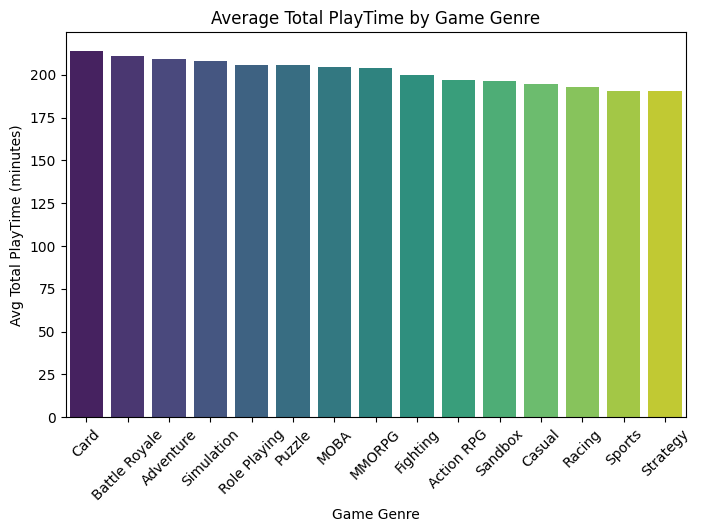

In [19]:
# Average TotalPlayTime by GameGenre
genre_engagement = df.groupby('GameGenre')['TotalPlayTime'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=genre_engagement.index, y=genre_engagement.values, palette='viridis',hue = genre_engagement.index, legend=False)
plt.title('Average Total PlayTime by Game Genre')
plt.ylabel('Avg Total PlayTime (minutes)')
plt.xlabel('Game Genre')
plt.xticks(rotation=45)
plt.show()

**Insight:** The Card and Battle Royale genres have highest TotalPlayTime and most engaging game types.

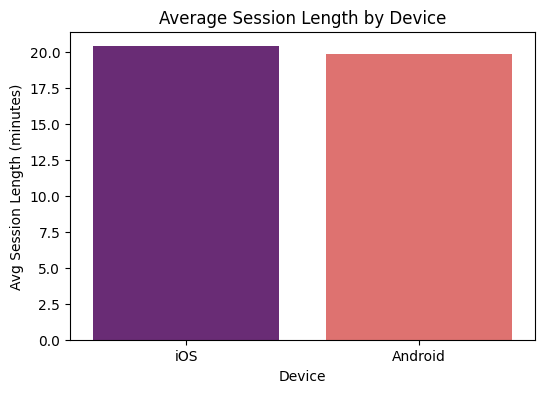

In [21]:
device_engagement = df.groupby('Device')['AverageSessionLength'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=device_engagement.index, y=device_engagement.values, palette='magma',hue = device_engagement.index, legend=False)
plt.title('Average Session Length by Device')
plt.ylabel('Avg Session Length (minutes)')
plt.xlabel('Device')
plt.show()

**Insight:** iOS users have slightly longer sessions (~0.5 min more)

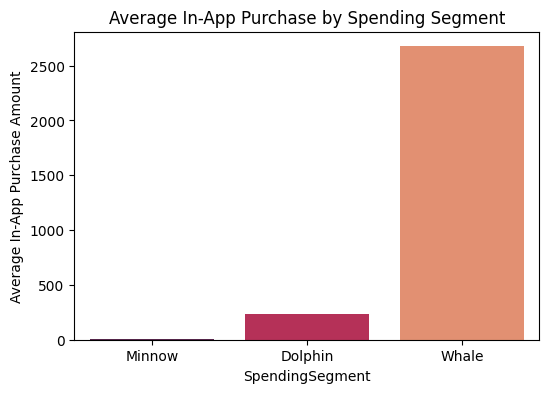

In [57]:
# SpendingSegment vs InAppPurchaseAmount
plt.figure(figsize=(6,4))
sns.barplot(x='SpendingSegment', y='InAppPurchaseAmount', data=df, estimator='mean', errorbar=None, hue = 'SpendingSegment', legend=False, palette='rocket')
plt.title('Average In-App Purchase by Spending Segment')
plt.ylabel('Average In-App Purchase Amount')
plt.show()

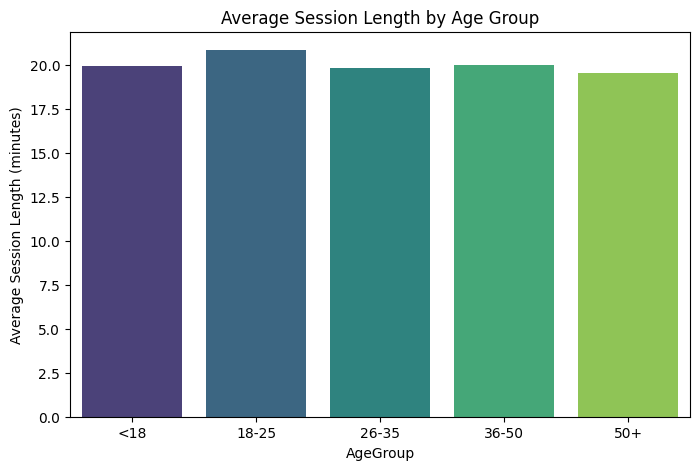

In [59]:
# AgeGroup vs AverageSessionLength
plt.figure(figsize=(8,5))
sns.barplot(x='AgeGroup', y='AverageSessionLength', data=df, errorbar=None, hue = 'AgeGroup', legend=False, palette='viridis')
plt.title('Average Session Length by Age Group')
plt.ylabel('Average Session Length (minutes)')
plt.show()

## Multivariant Analysis

/tmp/ipykernel_390/3172418657.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_engagement = df.groupby(['AgeGroup','Gender'])['TotalPlayTime'].mean().unstack()


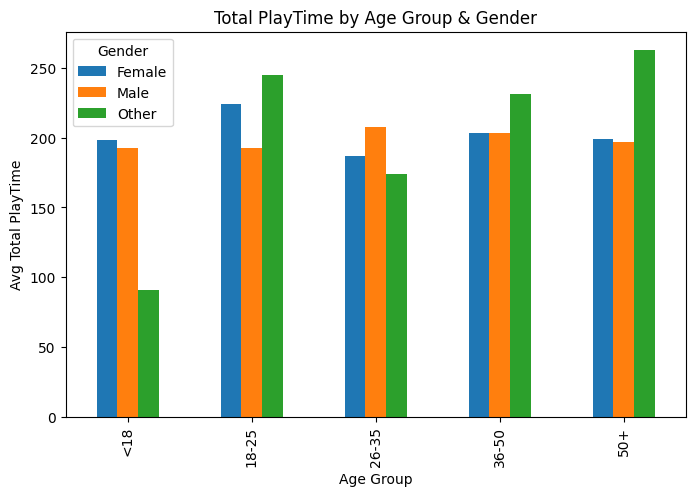

In [22]:
age_gender_engagement = df.groupby(['AgeGroup','Gender'])['TotalPlayTime'].mean().unstack()

age_gender_engagement.plot(kind='bar', figsize=(8,5))
plt.title('Total PlayTime by Age Group & Gender')
plt.ylabel('Avg Total PlayTime')
plt.xlabel('Age Group')
plt.show()

**Insights:**
1. Most engaged age group: 18–25 (especially females: 224.2 min)

2. Interesting pattern:  “Other” gender shows very high engagement in some age groups (18–25, 50+) → could be a niche segment

3. Engagement is relatively balanced across Male and Female in most age groups

/tmp/ipykernel_390/966033995.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spend = df.groupby(['AgeGroup','SpendingSegment'])['InAppPurchaseAmount'].mean().unstack()


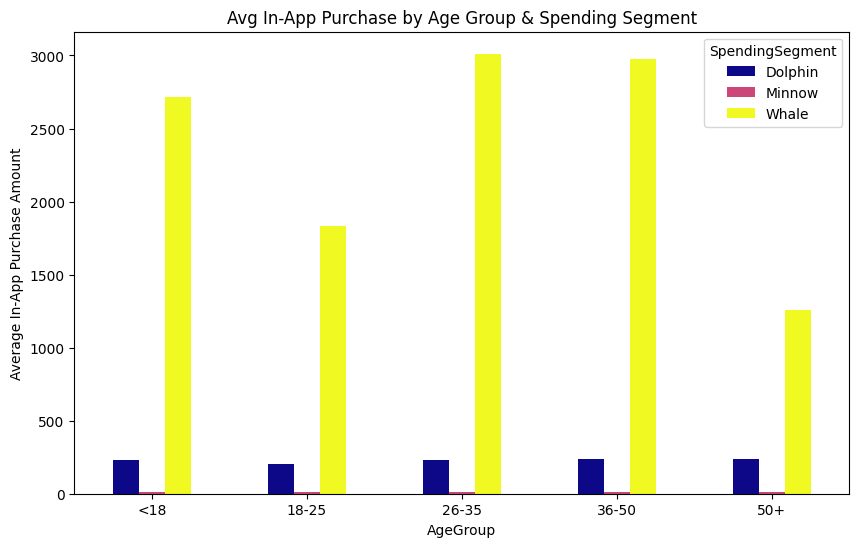

In [61]:
# AgeGroup + SpendingSegment vs InAppPurchaseAmount
age_spend = df.groupby(['AgeGroup','SpendingSegment'])['InAppPurchaseAmount'].mean().unstack()
age_spend.plot(kind='bar', figsize=(10,6), colormap='plasma')
plt.title('Avg In-App Purchase by Age Group & Spending Segment')
plt.ylabel('Average In-App Purchase Amount')
plt.xticks(rotation=0)
plt.show()

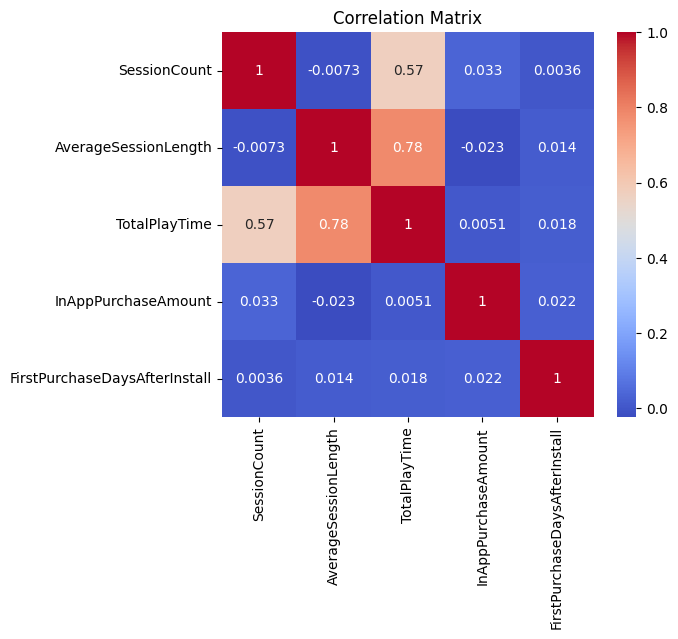

In [28]:
numeric_cols = ['SessionCount','AverageSessionLength','TotalPlayTime','InAppPurchaseAmount','FirstPurchaseDaysAfterInstall']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# **Insights :**

1. Players aged 18–25 are the most engaged, particularly females, suggesting targeted retention campaigns for this demographic.

2. Engagement is slightly higher on iOS than Android, indicating potential platform-specific optimization opportunities.

3. Niche “Other” gender segment shows high engagement in 18–25 and 50+ age groups, which could inform personalized in-game offers or content.

4. **Engagement drives total playtime:**

   a. Strong correlation between AverageSessionLength and TotalPlayTime (0.78)

   b. Shows that long sessions are more important than sheer session count for engagement.

5. **Spending not strongly tied to engagement:** TotalPlayTime vs InAppPurchaseAmount ~ 0.005 → highly engaged players don’t automatically spend more


6. **Timing of first purchase is independent:** Correlation with engagement and spend is very low